# REGIME-SHIFT — Stage 2: HMM + Walk-Forward Backtest
### India Macro-Aware Tactical Allocation Engine

**Inputs (from Stage 1):** `data/monthly/` — 168-month feature matrix + ETF returns  
**Assets traded:** NIFTYBEES · JUNIORBEES · GOLDBEES · LIQUIDBEES *(GILTBEES excluded — insufficient history)*  
**What this stage does:**
1. Fits a 3-state Hidden Markov Model → classifies each month as **Bull / Bear / Crisis**  
2. Runs a walk-forward backtest: annual HMM refit, monthly minimum-variance rebalancing  
3. Compares strategy vs NIFTYBEES buy-and-hold, equal-weight, and a static 60/40 proxy  


In [1]:
# Run once; comment out after first execution
import subprocess, sys
PKGS = ["hmmlearn>=0.3.0", "cvxpy>=1.4.0", "scikit-learn>=1.3.0"]
for p in PKGS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])
print("✓ Packages ready")


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✓ Packages ready


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import warnings, json
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

from hmmlearn.hmm          import GaussianHMM
from sklearn.covariance    import LedoitWolf
import cvxpy as cp

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

print("hmmlearn  :", __import__("hmmlearn").__version__)
print("cvxpy     :", cp.__version__)
print("sklearn   :", __import__("sklearn").__version__)


hmmlearn  : 0.3.3
cvxpy     : 1.7.5
sklearn   : 1.6.1


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ALL parameters live here.  Change here → affects the entire Stage 2 pipeline.
# ═══════════════════════════════════════════════════════════════════════════════

# ── Inherited from Stage 1 ────────────────────────────────────────────────────
DATA_DIR        = Path("data")
BACKTEST_START  = "2010-01-01"
BACKTEST_END    = "2023-12-31"
HOLDOUT_START   = "2024-01-01"
HOLDOUT_END     = "2024-12-31"
RISK_FREE_ANNUAL = 0.065
RF_MONTHLY       = RISK_FREE_ANNUAL / 12

# ── Assets (GILTBEES dropped — insufficient history) ─────────────────────────
ASSET_NAMES = ["NIFTYBEES", "JUNIORBEES", "GOLDBEES", "LIQUIDBEES"]
N_ASSETS    = len(ASSET_NAMES)

# ── Transaction costs: one-way in basis points ────────────────────────────────
TC_ONE_WAY = np.array([10, 10, 5, 3]) / 10_000

# ── HMM parameters ────────────────────────────────────────────────────────────
# Broad-regime walk-forward engine: risk-on Bull vs risk-off Crisis.
# Rolling Stage 3 showed this is the robust specification: it avoids a tiny,
# overfit Bull state and lands near the expected 60-70% bullish share.
HMM_N_STATES   = 2
HMM_COV_TYPE   = "diag"
HMM_N_ITER     = 500
HMM_N_INIT     = 20
HMM_SEED       = 42

# Core HMM features. Stage 1 may save extra diagnostics; keep the model input lean.
HMM_FEATURE_COLUMNS = [
    "nifty_mom_z",
    "realized_vol_z",
    "vix_z",
    "inr_stress",
    "gsec_mom_z",
    "trend_quality_z",
]

STATE_SCORE_WEIGHTS = {
    "nifty_mom_z":        0.35,
    "trend_quality_z":    0.15,
    "realized_vol_z":    -1.00,
    "vix_z":             -0.25,
    "inr_stress":        -0.10,
    "gsec_mom_z":        -0.05,
}

# ── Walk-forward parameters ───────────────────────────────────────────────────
INITIAL_TRAIN_END = "2014-12-31"
TEST_START        = "2015-01-01"
COV_WINDOW        = 36

# ── Portfolio weight bounds per regime ────────────────────────────────────────
# Bear remains available for experiments, but the default HMM now emits
# Bull/Crisis broad regimes.
REGIME_BOUNDS = {
    "Bull": [
        (0.35, 0.65),
        (0.10, 0.30),
        (0.00, 0.15),
        (0.05, 0.15),
    ],
    "Bear": [
        (0.10, 0.35),
        (0.00, 0.15),
        (0.15, 0.35),
        (0.20, 0.40),
    ],
    "Crisis": [
        (0.00, 0.10),
        (0.00, 0.05),
        (0.40, 0.60),
        (0.35, 0.55),
    ],
}

GROUP_EQUITY    = [0, 1]
GROUP_DEFENSIVE = [2, 3]
GROUP_LIMITS = {
    "Bull":   {"equity_max": 0.80, "defensive_min": 0.05},
    "Bear":   {"equity_max": 0.50, "defensive_min": 0.40},
    "Crisis": {"equity_max": 0.15, "defensive_min": 0.70},
}

REGIME_COLORS  = {"Bull": "#27AE60", "Bear": "#E67E22", "Crisis": "#C0392B"}
REGIME_LABELS  = {0: "Bull", 1: "Crisis"}

print("✓ Config loaded")
print(f"  Assets       : {ASSET_NAMES}")
print(f"  TC (bps)     : {(TC_ONE_WAY * 10_000).astype(int).tolist()}")
print(f"  HMM states   : {HMM_N_STATES} broad regimes  |  n_init={HMM_N_INIT}  |  cov={HMM_COV_TYPE}")
print(f"  HMM features : {HMM_FEATURE_COLUMNS}")
print(f"  Walk-forward : train through {INITIAL_TRAIN_END}, test from {TEST_START}")


✓ Config loaded
  Assets       : ['NIFTYBEES', 'JUNIORBEES', 'GOLDBEES', 'LIQUIDBEES']
  TC (bps)     : [10, 10, 5, 2]
  HMM states   : 2 broad regimes  |  n_init=20  |  cov=diag
  HMM features : ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z']
  Walk-forward : train through 2014-12-31, test from 2015-01-01


In [4]:
# ── Load monthly HMM features ─────────────────────────────────────────────────
feat_train_all   = pd.read_parquet(DATA_DIR / "monthly" / "hmm_features_train.parquet")
feat_holdout_all = pd.read_parquet(DATA_DIR / "monthly" / "hmm_features_holdout.parquet")

missing_features = [c for c in HMM_FEATURE_COLUMNS if c not in feat_train_all.columns]
if missing_features:
    raise ValueError(f"Missing HMM feature columns from Stage 1 output: {missing_features}")

# Keep extra Stage 1 diagnostics in *_all, but feed only the lean core set to HMM.
feat_train   = feat_train_all[HMM_FEATURE_COLUMNS].copy()
feat_holdout = feat_holdout_all[HMM_FEATURE_COLUMNS].copy()

# ── Load monthly ETF returns — drop GILTBEES immediately ─────────────────────
ret_all   = pd.read_parquet(DATA_DIR / "monthly" / "etf_returns_train.parquet")
ret_train = ret_all[ASSET_NAMES].copy()

ret_holdout_all = pd.read_parquet(DATA_DIR / "monthly" / "etf_returns_holdout.parquet")
ret_holdout     = ret_holdout_all[ASSET_NAMES].copy()

# ── Load rebalance dates ──────────────────────────────────────────────────────
rebal_dates = pd.to_datetime(
    pd.read_csv(DATA_DIR / "monthly" / "rebalance_dates.csv")["rebal_date"]
)
train_rebal = rebal_dates[rebal_dates <= BACKTEST_END]
test_rebal  = train_rebal[train_rebal >= TEST_START]

print("✓ Stage 1 outputs loaded")
print(f"  Feature columns available : {list(feat_train_all.columns)}")
print(f"  HMM feature columns used  : {list(feat_train.columns)}")
print(f"  Train features           : {feat_train.shape}")
print(f"  Train returns            : {ret_train.shape}")


✓ Stage 1 outputs loaded
  Feature columns available : ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z', 'nifty_trend_126d_z']
  HMM feature columns used  : ['nifty_mom_z', 'realized_vol_z', 'vix_z', 'inr_stress', 'gsec_mom_z', 'trend_quality_z']
  Train features           : (168, 6)
  Train returns            : (168, 4)


## Section 2 — HMM Regime Classifier

The HMM reads **5 macro signals** every month and outputs one of three hidden states: **Bull**, **Bear**, or **Crisis**.

**Key concept:** the HMM never sees ETF prices. It only reads:
1. `nifty_mom_z` — Nifty 50 momentum (z-scored)
2. `realized_vol_z` — realised volatility of Nifty (z-scored)
3. `vix_z` — India VIX implied vol (z-scored)
4. `inr_stress` — USD/INR depreciation pressure (z-scored)
5. `gsec_mom_z` — G-Sec 10Y yield momentum (z-scored)

After fitting, states are **labelled** by sorting on mean Nifty momentum:  
- Highest momentum → **Bull**  
- Lowest momentum → **Crisis**  
- Middle → **Bear**


In [5]:
# ── Clip sigma for HMM features ───────────────────────────────────────────────
# Features are 12-month rolling z-scores.  Clip at ±3.5σ to preserve genuine
# stress information while still preventing a single outlier from dominating EM.
CLIP_SIGMA = 3.5

def prepare_hmm_data(features: pd.DataFrame,
                     clip_sigma: float = CLIP_SIGMA) -> tuple:
    clean = features.dropna()
    X     = np.clip(clean.values, -clip_sigma, clip_sigma)
    return X, clean.index


def fit_hmm(X: np.ndarray,
            n_states: int = HMM_N_STATES,
            n_init:   int = HMM_N_INIT,
            n_iter:   int = HMM_N_ITER,
            seed:     int = HMM_SEED) -> GaussianHMM:
    best_model = None
    best_score = -np.inf

    for i in range(n_init):
        model = GaussianHMM(
            n_components    = n_states,
            covariance_type = HMM_COV_TYPE,
            n_iter          = n_iter,
            random_state    = seed + i,
            verbose         = False,
        )
        try:
            model.fit(X)
            score = model.score(X)
            if score > best_score:
                best_score = score
                best_model = model
        except Exception:
            continue

    assert best_model is not None, "All HMM initialisations failed — check input data"
    return best_model


def align_state_labels(model: GaussianHMM,
                       X: np.ndarray,
                       feature_names = None) -> dict:
    """
    Map HMM states to economic labels using a broad risk-on score.
    High score = Bull, low score = Crisis.  A 3-state experiment keeps Bear
    as the middle state.
    """
    if feature_names is None:
        feature_names = HMM_FEATURE_COLUMNS
    feature_names = list(feature_names)

    states = model.predict(X)
    n      = model.n_components
    scores = {}

    for s in range(n):
        mask = states == s
        vals = X[mask] if mask.sum() > 0 else model.means_[s:s+1]
        scores[s] = sum(
            STATE_SCORE_WEIGHTS.get(col, 0.0) * vals[:, j].mean()
            for j, col in enumerate(feature_names)
        )

    sorted_states = sorted(scores, key=scores.get, reverse=True)

    if n == 2:
        labels = ["Bull", "Crisis"]
    elif n == 3:
        labels = ["Bull", "Bear", "Crisis"]
    else:
        labels = ["Bull"] + [f"Regime{i}" for i in range(1, n - 1)] + ["Crisis"]

    return {sorted_states[i]: labels[i] for i in range(n)}


print("✓ HMM functions defined")
print(f"  prepare_hmm_data() — drops NaN rows, clips at ±{CLIP_SIGMA} sigma")
print(f"  fit_hmm()          — fits {HMM_N_STATES}-state {HMM_COV_TYPE} HMM")
print("  align_state_labels() — broad risk-on score → Bull/Crisis")


✓ HMM functions defined
  prepare_hmm_data() — drops NaN rows, clips at ±3.5 sigma
  fit_hmm()          — fits 2-state diag HMM
  align_state_labels() — broad risk-on score → Bull/Crisis


In [6]:
# Fit the HMM on the complete training window (2010–2023).
# This is for VISUALISATION only — it uses all training data at once.
# The walk-forward backtest in Section 4 re-fits year by year with no look-ahead.

X_full, idx_full = prepare_hmm_data(feat_train)

print(f"HMM input: {X_full.shape[0]} complete months out of {len(feat_train)} total")
print(f"  Dropped (NaN rows): {len(feat_train) - X_full.shape[0]} months")
print(f"  First complete obs: {idx_full[0].date()}")
print(f"\nFitting HMM ({HMM_N_INIT} random starts) …", end=" ")

hmm_full = fit_hmm(X_full)
label_map_full = align_state_labels(hmm_full, X_full)
print("done")

# Decode states for all complete months
raw_states_full = hmm_full.predict(X_full)
regime_labels_full = pd.Series(
    [label_map_full[s] for s in raw_states_full],
    index=idx_full,
    name="regime"
)

# Summary
counts = regime_labels_full.value_counts()
print(f"\nLog-likelihood   : {hmm_full.score(X_full):.1f}")
print(f"\nFull-sample regime distribution:")
for label in ["Bull", "Bear", "Crisis"]:   # all 3 regimes
    n = counts.get(label, 0)
    pct = n / len(regime_labels_full) * 100
    bar = "█" * int(pct / 2)
    print(f"  {label:7s}: {n:3d} months ({pct:4.1f}%)  {bar}")


HMM input: 139 complete months out of 168 total
  Dropped (NaN rows): 29 months
  First complete obs: 2012-05-31

Fitting HMM (20 random starts) … done

Log-likelihood   : -1154.3

Full-sample regime distribution:
  Bull   :  91 months (65.5%)  ████████████████████████████████
  Bear   :   0 months ( 0.0%)  
  Crisis :  48 months (34.5%)  █████████████████


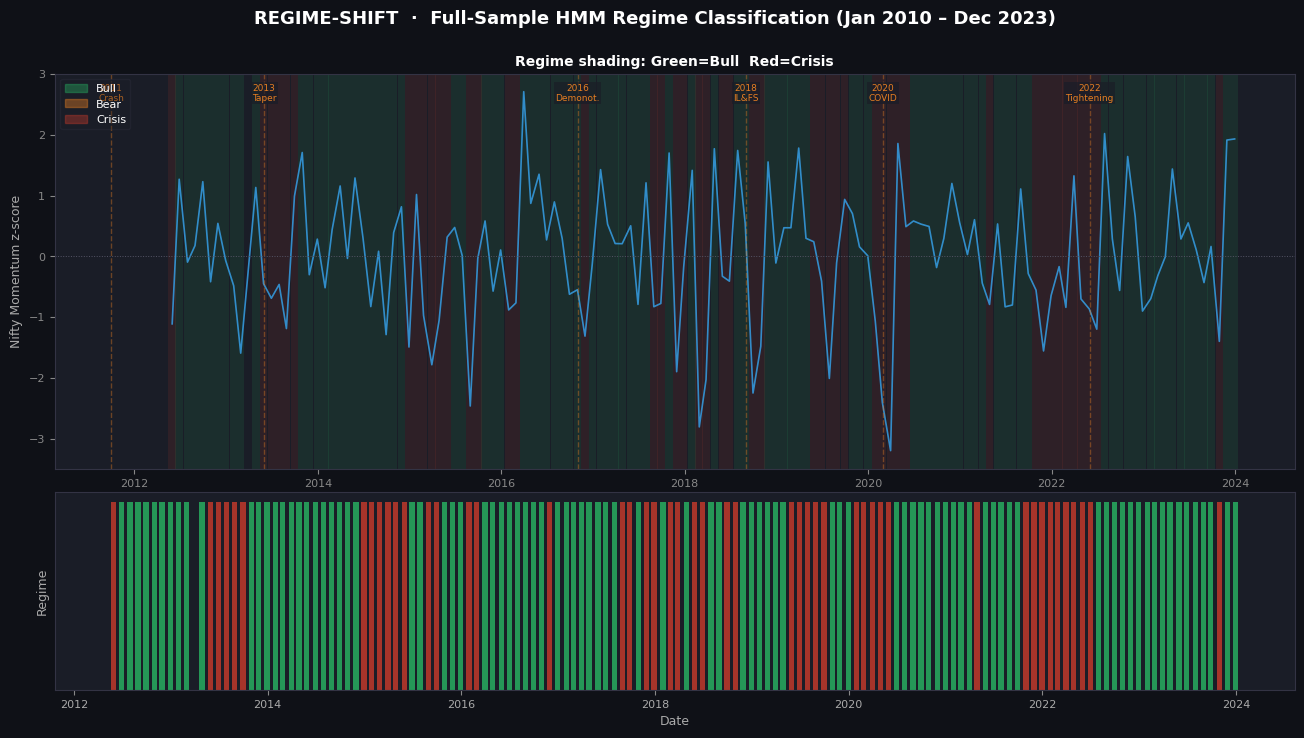

✓ Saved: data/stage2_regime_timeline.png


In [7]:
# ── Plot: Nifty price + regime shading + key market events ───────────────────
nifty_monthly = feat_train["nifty_mom_z"].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8),
                                facecolor="#0F1117",
                                gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

fig.suptitle("REGIME-SHIFT  ·  Full-Sample HMM Regime Classification (Jan 2010 – Dec 2023)",
             color="white", fontsize=13, fontweight="bold", y=0.96)

AX_BG = "#1A1D27"
TITLE_KW = dict(color="white", fontsize=10, fontweight="bold")

EVENTS = {
    "2011-10": "2011\nCrash",
    "2013-06": "2013\nTaper",
    "2016-11": "2016\nDemonot.",
    "2018-09": "2018\nIL&FS",
    "2020-03": "2020\nCOVID",
    "2022-06": "2022\nTightening",
}

for ax in (ax1, ax2):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors="#888888", labelsize=8)
    ax.spines[:].set_color("#333344")

# Panel 1: Nifty momentum + regime shading
ax1.plot(regime_labels_full.index, X_full[:, 0],
         color="#3498DB", lw=1.2, alpha=0.9, label="Nifty mom z-score")
ax1.axhline(0, color="#555566", lw=0.7, ls=":")

for dt_str, label in EVENTS.items():
    dt = pd.Timestamp(dt_str)
    ax1.axvline(dt, color="#E67E22", alpha=0.4, lw=1, ls="--")
    ax1.text(dt, ax1.get_ylim()[1] * 0.85 if ax1.get_ylim()[1] > 0 else -2,
             label, color="#E67E22", fontsize=6.5, ha="center", rotation=0,
             bbox=dict(facecolor=AX_BG, edgecolor="none", alpha=0.7, pad=1))

for regime, color in REGIME_COLORS.items():
    mask = regime_labels_full == regime
    for date in regime_labels_full[mask].index:
        ax1.axvspan(date - pd.DateOffset(days=15),
                    date + pd.DateOffset(days=15),
                    alpha=0.12, color=color, lw=0)

ax1.set_ylabel("Nifty Momentum z-score", color="#AAAAAA", fontsize=9)
ax1.set_title("Regime shading: Green=Bull  Red=Crisis", **TITLE_KW)

# Legend
patches = [mpatches.Patch(color=c, alpha=0.4, label=r)
           for r, c in REGIME_COLORS.items()]
ax1.legend(handles=patches, loc="upper left",
           fontsize=8, framealpha=0.3, facecolor=AX_BG,
           edgecolor="#333344", labelcolor="white")

# Panel 2: Regime timeline bar
regime_num = regime_labels_full.map({"Bull": 1, "Crisis": 0})
ax2.bar(regime_num.index, [1]*len(regime_num),
        color=regime_labels_full.map(REGIME_COLORS),
        width=20, alpha=0.85)
ax2.set_yticks([])
ax2.set_ylabel("Regime", color="#AAAAAA", fontsize=9)
ax2.set_xlabel("Date", color="#AAAAAA", fontsize=9)
for lbl in ax2.get_xticklabels(): lbl.set_color("#AAAAAA")

plt.savefig(DATA_DIR / "stage2_regime_timeline.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: data/stage2_regime_timeline.png")


In [8]:
# ── Regime statistics: what each state looks like ─────────────────────────────
print("Regime Statistics — Full Training Sample")
print("=" * 65)

feat_names = list(feat_train.columns)

for regime in ["Bull", "Bear", "Crisis"]:
    mask = regime_labels_full == regime
    if mask.sum() == 0:
        continue
    regime_months = regime_labels_full.index[mask]

    # Feature means in this regime
    regime_feats = feat_train.loc[regime_months].mean().round(3)

    # ETF returns in this regime
    regime_rets  = ret_train.loc[ret_train.index.isin(regime_months)]
    ann_rets     = regime_rets.mean() * 12

    color_sym = {"Bull": "🟢", "Bear": "🟡", "Crisis": "🔴"}.get(regime, "⚪")
    print(f"\n{color_sym} {regime}  ({mask.sum()} months, {mask.mean():.0%})")
    print("  Feature means:")
    for feat, val in regime_feats.items():
        bar = "▲" if val > 0.3 else ("▼" if val < -0.3 else "—")
        print(f"    {feat:22s}: {val:+.3f}  {bar}")
    print("  Annualised ETF returns:")
    for asset, ret in ann_rets.items():
        print(f"    {asset:12s}: {ret:+.1%}")


Regime Statistics — Full Training Sample

🟢 Bull  (91 months, 65%)
  Feature means:
    nifty_mom_z           : +0.419  ▲
    realized_vol_z        : -0.735  ▼
    vix_z                 : -0.586  ▼
    inr_stress            : -0.424  ▼
    gsec_mom_z            : +0.023  —
    trend_quality_z       : +0.493  ▲
  Annualised ETF returns:
    NIFTYBEES   : +33.4%
    JUNIORBEES  : +36.3%
    GOLDBEES    : -1.8%
    LIQUIDBEES  : +4.5%

🔴 Crisis  (48 months, 35%)
  Feature means:
    nifty_mom_z           : -0.800  ▼
    realized_vol_z        : +1.116  ▲
    vix_z                 : +0.645  ▲
    inr_stress            : +0.894  ▲
    gsec_mom_z            : +0.189  —
    trend_quality_z       : -0.756  ▼
  Annualised ETF returns:
    NIFTYBEES   : -20.8%
    JUNIORBEES  : -20.3%
    GOLDBEES    : +22.1%
    LIQUIDBEES  : +4.0%


## Section 3 — Portfolio Optimizer

For every rebalance date, the optimizer solves:

$$\min_w \; w^\top \Sigma w + \lambda \cdot \text{TC}(w, w_{\text{prev}})$$

subject to:
- $\sum_i w_i = 1$ (fully invested)
- $lb_i \leq w_i \leq ub_i$ (per-asset bounds — **different per regime**)
- Group constraints (total equity cap, total defensive floor)

**The objective never uses expected returns** — only the covariance matrix $\Sigma$.  
This removes the noisiest input and makes the strategy robust and easy to explain:  
> *"We always minimise risk. The regime controls how much risk we're allowed to take."*

**Covariance estimation:** Ledoit-Wolf shrinkage on the trailing 36 months of returns.


In [9]:
def estimate_covariance(ret_window: pd.DataFrame) -> np.ndarray:
    """
    Ledoit-Wolf shrinkage covariance estimator.
    
    Why Ledoit-Wolf?  A raw sample covariance from only 36 monthly returns
    is noisy. Ledoit-Wolf shrinks off-diagonal entries toward zero —
    meaning we're conservative about how correlated assets really are.
    Returns an annualised covariance matrix.
    """
    R = ret_window.dropna().values
    if R.shape[0] < 6:
        # Fallback: diagonal matrix (assume no correlation)
        vols = np.nanstd(ret_window.values, axis=0)
        return np.diag(vols ** 2) * 12
    lw = LedoitWolf()
    lw.fit(R)
    return lw.covariance_ * 12   # annualise


def optimise_portfolio(Sigma:    np.ndarray,
                       regime:   str,
                       w_prev:   np.ndarray,
                       asset_names: list = ASSET_NAMES) -> np.ndarray:
    """
    CVXPY minimum-variance optimizer with:
    - Per-asset weight bounds (from REGIME_BOUNDS[regime])
    - Group concentration limits (from GROUP_LIMITS[regime])
    - Transaction cost penalty (from TC_ONE_WAY)
    
    If the solver fails or is infeasible, falls back to equal weight within bounds.
    """
    n    = len(asset_names)
    w    = cp.Variable(n)
    lbs  = np.array([b[0] for b in REGIME_BOUNDS[regime]])
    ubs  = np.array([b[1] for b in REGIME_BOUNDS[regime]])
    
    # Turnover (one-way) = sum of absolute weight changes / 2
    turnover = cp.sum(cp.abs(w - w_prev))
    tc_cost  = TC_ONE_WAY @ cp.abs(w - w_prev)   # per-asset cost × change
    
    constraints = [
        cp.sum(w) == 1,              # fully invested
        w >= lbs,                    # per-asset lower bounds
        w <= ubs,                    # per-asset upper bounds
        # Group: equity concentration
        cp.sum(w[GROUP_EQUITY])    <= GROUP_LIMITS[regime]["equity_max"],
        # Group: defensive floor
        cp.sum(w[GROUP_DEFENSIVE]) >= GROUP_LIMITS[regime]["defensive_min"],
    ]
    
    objective = cp.Minimize(
        cp.quad_form(w, Sigma) + tc_cost
    )
    
    prob = cp.Problem(objective, constraints)
    
    try:
        prob.solve(solver=cp.CLARABEL, verbose=False)
        if prob.status in ("optimal", "optimal_inaccurate") and w.value is not None:
            weights = np.clip(w.value, 0, 1)
            weights /= weights.sum()   # re-normalise for numerical precision
            return weights
    except Exception:
        pass
    
    # Fallback: equal weight within lower bounds (always feasible)
    print(f"    ⚠  Solver failed for {regime} regime — using equal-weight fallback")
    w_fallback = lbs.copy()
    remainder  = 1.0 - w_fallback.sum()
    w_fallback += remainder / n
    w_fallback  = np.clip(w_fallback, lbs, ubs)
    w_fallback /= w_fallback.sum()
    return w_fallback


print("✓ Optimizer functions defined")
print("  estimate_covariance()  — Ledoit-Wolf, annualised, 36-month window")
print("  optimise_portfolio()   — CVXPY min-variance + TC penalty + bounds")


✓ Optimizer functions defined
  estimate_covariance()  — Ledoit-Wolf, annualised, 36-month window
  optimise_portfolio()   — CVXPY min-variance + TC penalty + bounds


In [10]:
# Quick sanity test: run the optimizer once for each regime
print("Optimizer sanity check — using full-sample covariance:")
Sigma_test = estimate_covariance(ret_train)

w_equal = np.array([0.25, 0.25, 0.25, 0.25])
for regime in ["Bull", "Bear", "Crisis"]:
    w = optimise_portfolio(Sigma_test, regime, w_equal)
    print(f"\n  {regime}:")
    for name, wi in zip(ASSET_NAMES, w):
        bar = "█" * int(wi * 30)
        print(f"    {name:12s}: {wi:.1%}  {bar}")
    print(f"    Sum = {w.sum():.4f}  |  Equity = {w[GROUP_EQUITY].sum():.1%}"
          f"  |  Defensive = {w[GROUP_DEFENSIVE].sum():.1%}")


Optimizer sanity check — using full-sample covariance:

  Bull:
    NIFTYBEES   : 45.0%  █████████████
    JUNIORBEES  : 25.0%  ███████
    GOLDBEES    : 15.0%  ████
    LIQUIDBEES  : 15.0%  ████
    Sum = 1.0000  |  Equity = 70.0%  |  Defensive = 30.0%

  Bear:
    NIFTYBEES   : 19.9%  █████
    JUNIORBEES  : 6.8%  ██
    GOLDBEES    : 33.3%  █████████
    LIQUIDBEES  : 40.0%  ███████████
    Sum = 1.0000  |  Equity = 26.7%  |  Defensive = 73.3%

  Crisis:
    NIFTYBEES   : 5.9%  █
    JUNIORBEES  : 3.3%  
    GOLDBEES    : 40.0%  ███████████
    LIQUIDBEES  : 50.8%  ███████████████
    Sum = 1.0000  |  Equity = 9.2%  |  Defensive = 90.8%


## Section 4 — Walk-Forward Backtest

**No look-ahead bias:** the HMM is refitted at the START of each year using only data  
available at that point. Weights for February 2016 only use information available in January 2016.

**Sequence for each year Y (2015 → 2023):**
1. **Refit HMM** on features from `2010-01` to `end of year Y-1` (expanding window)
2. **Each month in year Y:** decode regime → estimate covariance → solve optimizer → record weights
3. **Portfolio return** for month T = weights decided at T-1 × ETF returns at T


In [11]:
def walk_forward_backtest(feat_train:  pd.DataFrame,
                          ret_train:   pd.DataFrame,
                          test_dates:  pd.DatetimeIndex) -> pd.DataFrame:
    """
    Annual HMM refit + monthly minimum-variance rebalancing.
    
    Returns a DataFrame with one row per rebalance date containing:
      regime, weights (one column per asset), portfolio_return, turnover
    """
    # Convert to DatetimeIndex once here — test_rebal loads from CSV as a
    # Series with integer index labels, so future[0] would fail with KeyError.
    # DatetimeIndex supports clean positional indexing and .year directly.
    test_dates = pd.DatetimeIndex(test_dates)

    results       = []
    current_model = None
    current_labels= None
    w_prev        = np.ones(N_ASSETS) / N_ASSETS   # start: equal weight

    # Pre-group test dates by year so we can refit once per year
    test_years = sorted(set(test_dates.year))

    for year in test_years:
        # ── 1. Annual HMM refit on expanding training window ─────────────────
        train_cutoff = pd.Timestamp(f"{year - 1}-12-31")
        X_train, _   = prepare_hmm_data(feat_train.loc[:train_cutoff])

        if len(X_train) >= 24:   # need at least 24 complete months
            current_model  = fit_hmm(X_train)
            current_labels = align_state_labels(current_model, X_train)
            n_train = len(X_train)
            print(f"  {year}: HMM refit on {n_train} complete months "
                  f"through {train_cutoff.date()}")
        else:
            print(f"  {year}: insufficient data ({len(X_train)} months) "
                  f"— reusing previous model")

        # ── 2. Monthly rebalancing within this year ───────────────────────────
        year_dates = [d for d in test_dates if d.year == year]

        for rebal_date in year_dates:
            # Decode current regime
            X_to_date, _ = prepare_hmm_data(feat_train.loc[:rebal_date])
            if current_model is not None and len(X_to_date) > 0:
                viterbi   = current_model.predict(X_to_date)
                raw_state = viterbi[-1]
                regime    = current_labels.get(raw_state, "Crisis")
            else:
                regime = "Crisis"   # safe default before first valid fit

            # Estimate covariance from trailing COV_WINDOW months
            ret_window = (ret_train
                          .loc[:rebal_date]
                          .iloc[-COV_WINDOW:])
            Sigma = estimate_covariance(ret_window)

            # Solve optimizer
            w_new = optimise_portfolio(Sigma, regime, w_prev)

            # Portfolio return for NEXT month
            # Find the next rebalance date in the test set
            future = test_dates[test_dates > rebal_date]
            if len(future) > 0:
                next_date  = future[0]
                # Only use dates in ret_train (no holdout peeking)
                if next_date in ret_train.index:
                    next_ret   = ret_train.loc[next_date, ASSET_NAMES].fillna(0).values
                    port_ret   = float(w_new @ next_ret)
                else:
                    port_ret   = np.nan   # next date is in holdout — don't record
            else:
                port_ret = np.nan

            # Turnover = sum of absolute weight changes / 2
            turnover = float(np.abs(w_new - w_prev).sum() / 2)

            results.append({
                "date":       rebal_date,
                "regime":     regime,
                "port_return": port_ret,
                "turnover":   turnover,
                **{f"w_{a}": w_new[i] for i, a in enumerate(ASSET_NAMES)},
            })

            w_prev = w_new.copy()

    df = pd.DataFrame(results).set_index("date")
    df.index = pd.to_datetime(df.index)
    return df


print("✓ Walk-forward engine defined")


✓ Walk-forward engine defined


In [12]:
print("Running walk-forward backtest …")
print(f"  Test period: {TEST_START} → {BACKTEST_END}")
print(f"  {len(test_rebal)} monthly rebalance dates\n")

wf_results = walk_forward_backtest(feat_train, ret_train, test_rebal)

# Drop the last row if its portfolio_return is NaN (no next-month return)
wf_results = wf_results.dropna(subset=["port_return"])

print(f"\n✓ Backtest complete: {len(wf_results)} monthly returns")
print(f"  Period: {wf_results.index[0].date()} → {wf_results.index[-1].date()}")
print(f"  Regime counts: {wf_results['regime'].value_counts().to_dict()}")
print(f"  Avg monthly turnover: {wf_results['turnover'].mean():.1%}")


Running walk-forward backtest …
  Test period: 2015-01-01 → 2023-12-31
  108 monthly rebalance dates

  2015: HMM refit on 31 complete months through 2014-12-31
  2016: HMM refit on 43 complete months through 2015-12-31
  2017: HMM refit on 55 complete months through 2016-12-31
  2018: HMM refit on 67 complete months through 2017-12-31
  2019: HMM refit on 79 complete months through 2018-12-31
  2020: HMM refit on 91 complete months through 2019-12-31
  2021: HMM refit on 103 complete months through 2020-12-31
  2022: HMM refit on 115 complete months through 2021-12-31
  2023: HMM refit on 127 complete months through 2022-12-31

✓ Backtest complete: 107 monthly returns
  Period: 2015-01-29 → 2023-11-30
  Regime counts: {'Bull': 66, 'Crisis': 41}
  Avg monthly turnover: 18.9%


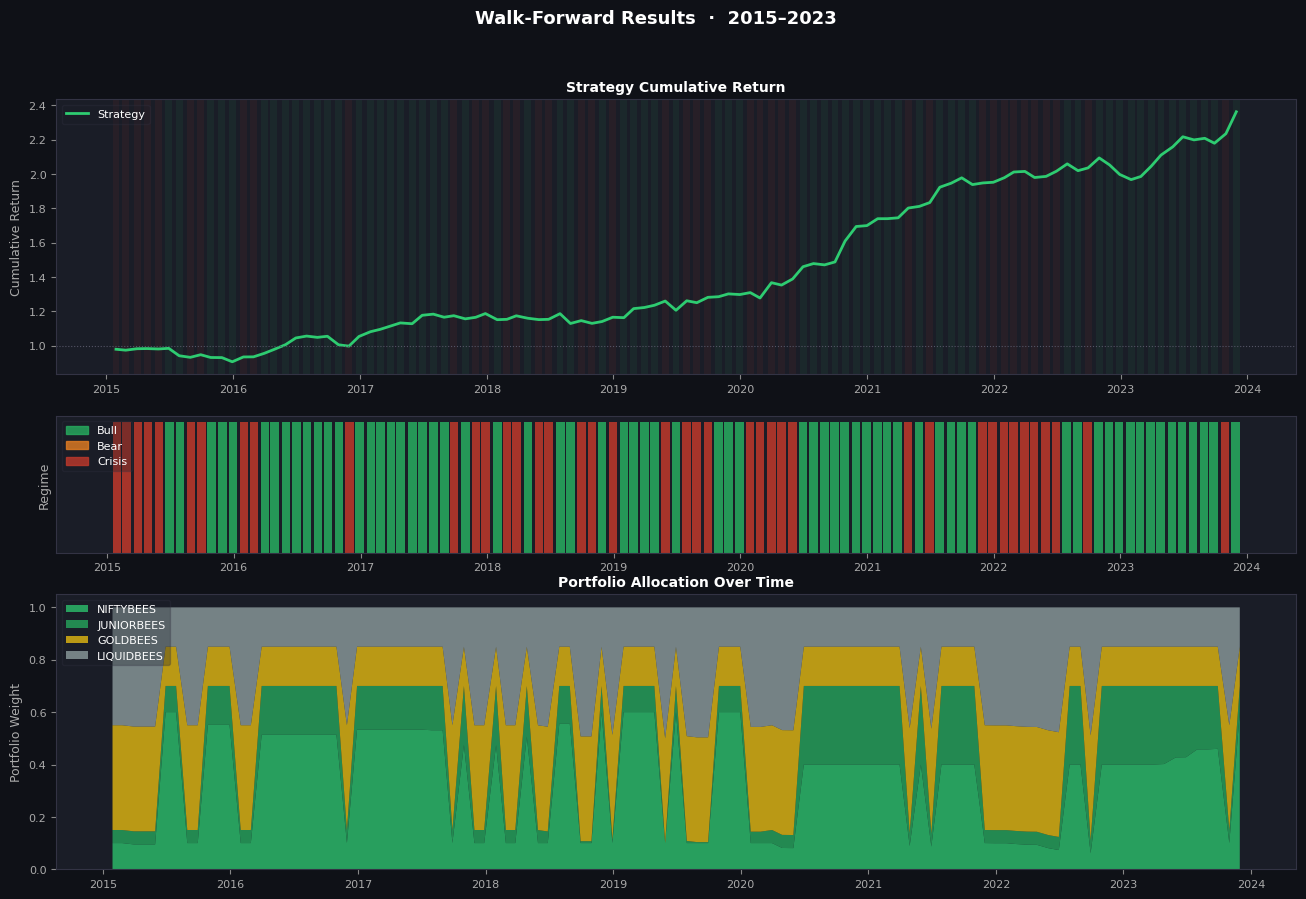

✓ Saved: data/stage2_walkforward.png


In [13]:
# ── Walk-forward regime timeline + weight evolution ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), facecolor="#0F1117",
                         gridspec_kw={"height_ratios": [2, 1, 2], "hspace": 0.18})
fig.suptitle("Walk-Forward Results  ·  2015–2023", color="white",
             fontsize=13, fontweight="bold", y=0.97)

AX_BG = "#1A1D27"
for ax in axes:
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors="#888888", labelsize=8)
    ax.spines[:].set_color("#333344")
    for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color("#AAAAAA")

# Panel 1: Cumulative strategy return
ax0 = axes[0]
cum_ret = (1 + wf_results["port_return"]).cumprod()
ax0.plot(cum_ret.index, cum_ret.values, color="#2ECC71", lw=2, label="Strategy")
ax0.axhline(1, color="#555566", lw=0.8, ls=":")
ax0.set_ylabel("Cumulative Return", color="#AAAAAA", fontsize=9)
ax0.set_title("Strategy Cumulative Return", color="white", fontsize=10, fontweight="bold")
ax0.legend(fontsize=8, framealpha=0.3, facecolor=AX_BG, labelcolor="white", edgecolor="#333344")

# Shade regimes
for _, row in wf_results.iterrows():
    ax0.axvspan(row.name - pd.DateOffset(days=10),
                row.name + pd.DateOffset(days=10),
                alpha=0.08, color=REGIME_COLORS[row["regime"]], lw=0)

# Panel 2: Regime bar
ax1 = axes[1]
ax1.bar(wf_results.index, [1]*len(wf_results),
        color=wf_results["regime"].map(REGIME_COLORS),
        width=25, alpha=0.85)
ax1.set_yticks([])
ax1.set_ylabel("Regime", color="#AAAAAA", fontsize=9)
patches = [mpatches.Patch(color=c, label=r, alpha=0.8)
           for r, c in REGIME_COLORS.items()]
ax1.legend(handles=patches, loc="upper left", fontsize=8,
           framealpha=0.3, facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

# Panel 3: Stacked weight area chart
ax2 = axes[2]
w_cols = [f"w_{a}" for a in ASSET_NAMES]
palette = ["#2ECC71", "#27AE60", "#F1C40F", "#95A5A6"]
ax2.stackplot(wf_results.index,
              [wf_results[c] for c in w_cols],
              labels=ASSET_NAMES, colors=palette, alpha=0.75)
ax2.set_ylabel("Portfolio Weight", color="#AAAAAA", fontsize=9)
ax2.set_title("Portfolio Allocation Over Time", color="white", fontsize=10, fontweight="bold")
ax2.legend(loc="upper left", fontsize=8, framealpha=0.3,
           facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

plt.savefig(DATA_DIR / "stage2_walkforward.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: data/stage2_walkforward.png")


## Section 5 — Performance Analytics

Comparing the strategy against three static benchmarks:
1. **NIFTYBEES B&H** — buy and hold NIFTYBEES, do nothing
2. **Equal Weight** — 25% each of all 4 assets, rebalanced monthly
3. **60/40 India** — 60% NIFTYBEES + 40% GOLDBEES+LIQUIDBEES split evenly (India equivalent of 60/40 without bonds)

All benchmarks apply the same transaction cost model on their rebalancing trades.


In [14]:
def performance_metrics(returns: pd.Series, label: str = "") -> dict:
    """
    Compute all key risk-adjusted performance metrics from a monthly return series.
    All annualisation uses 12 months (monthly data).
    """
    r  = returns.dropna()
    n  = len(r)
    rf = RF_MONTHLY

    # Annualised return (geometric)
    cagr   = (1 + r).prod() ** (12 / n) - 1

    # Annualised volatility
    vol    = r.std() * np.sqrt(12)

    # Sharpe ratio
    sharpe = (r.mean() - rf) / (r.std() + 1e-10) * np.sqrt(12)

    # Sortino ratio (downside deviation only)
    downside = r[r < rf]
    dd_std   = downside.std() * np.sqrt(12) if len(downside) > 0 else 1e-10
    sortino  = (cagr - RISK_FREE_ANNUAL) / (dd_std + 1e-10)

    # Maximum drawdown
    cum  = (1 + r).cumprod()
    peak = cum.cummax()
    mdd  = ((cum - peak) / peak).min()

    # Calmar ratio
    calmar = cagr / abs(mdd) if mdd != 0 else 0.0

    return {
        "Strategy":    label,
        "CAGR":        f"{cagr:.1%}",
        "Ann. Vol":    f"{vol:.1%}",
        "Sharpe":      f"{sharpe:.2f}",
        "Sortino":     f"{sortino:.2f}",
        "Max DD":      f"{mdd:.1%}",
        "Calmar":      f"{calmar:.2f}",
        "Months":       n,
    }, {"cagr": cagr, "vol": vol, "sharpe": sharpe,
        "sortino": sortino, "mdd": mdd, "calmar": calmar}


def build_benchmark(weights: dict, ret_df: pd.DataFrame,
                    tc: np.ndarray = TC_ONE_WAY) -> pd.Series:
    """
    Static benchmark: rebalance to fixed weights monthly.
    TC applied as a drag on each rebalance.
    """
    w_target = np.array([weights.get(a, 0.0) for a in ASSET_NAMES])
    rets     = []
    w_prev   = w_target.copy()
    for date in ret_df.index:
        r = ret_df.loc[date, ASSET_NAMES].fillna(0).values
        # TC drag on rebalance trades
        turnover  = np.abs(w_target - w_prev).sum() / 2
        tc_drag   = (tc * np.abs(w_target - w_prev)).sum()
        port_ret  = float(w_target @ r) - tc_drag
        rets.append({"date": date, "return": port_ret})
        w_prev = w_target.copy()
    return pd.DataFrame(rets).set_index("date")["return"]


print("✓ Performance metric functions defined")


✓ Performance metric functions defined


In [15]:
# Align all series to the same test period
strategy_rets = wf_results["port_return"].dropna()
test_period   = strategy_rets.index

# Benchmark returns (same period)
ret_test = ret_train.loc[ret_train.index.isin(test_period)]

# 1. NIFTYBEES buy-and-hold (no rebalancing, one-time TC at start)
bh_rets    = ret_test["NIFTYBEES"]

# 2. Equal weight
ew_weights = {a: 1/N_ASSETS for a in ASSET_NAMES}
ew_rets    = build_benchmark(ew_weights, ret_test)

# 3. 60/40 India proxy (60% equity split, 40% defensive split)
india_6040 = {
    "NIFTYBEES" : 0.40,
    "JUNIORBEES": 0.20,
    "GOLDBEES"  : 0.25,
    "LIQUIDBEES": 0.15,
}
india_6040_rets = build_benchmark(india_6040, ret_test)

# ── Performance table ─────────────────────────────────────────────────────────
rows = []
raw  = {}
for label, rets in [
    ("REGIME-SHIFT",  strategy_rets),
    ("NIFTYBEES B&H", bh_rets),
    ("Equal Weight",  ew_rets),
    ("60/40 India",   india_6040_rets),
]:
    row, raw_vals = performance_metrics(rets, label)
    rows.append(row)
    raw[label] = raw_vals

perf_df = pd.DataFrame(rows).set_index("Strategy")

print("\n" + "=" * 65)
print("PERFORMANCE SUMMARY  (Walk-Forward Test Period: 2015–2023)")
print("=" * 65)
print(perf_df.to_string())
print("=" * 65)
print(f"\nRisk-free rate: {RISK_FREE_ANNUAL:.1%} (RBI repo rate, flat approximation)")



PERFORMANCE SUMMARY  (Walk-Forward Test Period: 2015–2023)
                CAGR Ann. Vol Sharpe Sortino  Max DD Calmar  Months
Strategy                                                           
REGIME-SHIFT   10.1%     8.2%   0.43    0.74   -8.0%   1.27     107
NIFTYBEES B&H  11.6%    16.9%   0.36    0.37  -31.0%   0.38     107
Equal Weight    9.9%     8.8%   0.38    0.55  -12.7%   0.78     107
60/40 India    10.6%    10.3%   0.40    0.55  -15.9%   0.67     107

Risk-free rate: 6.5% (RBI repo rate, flat approximation)


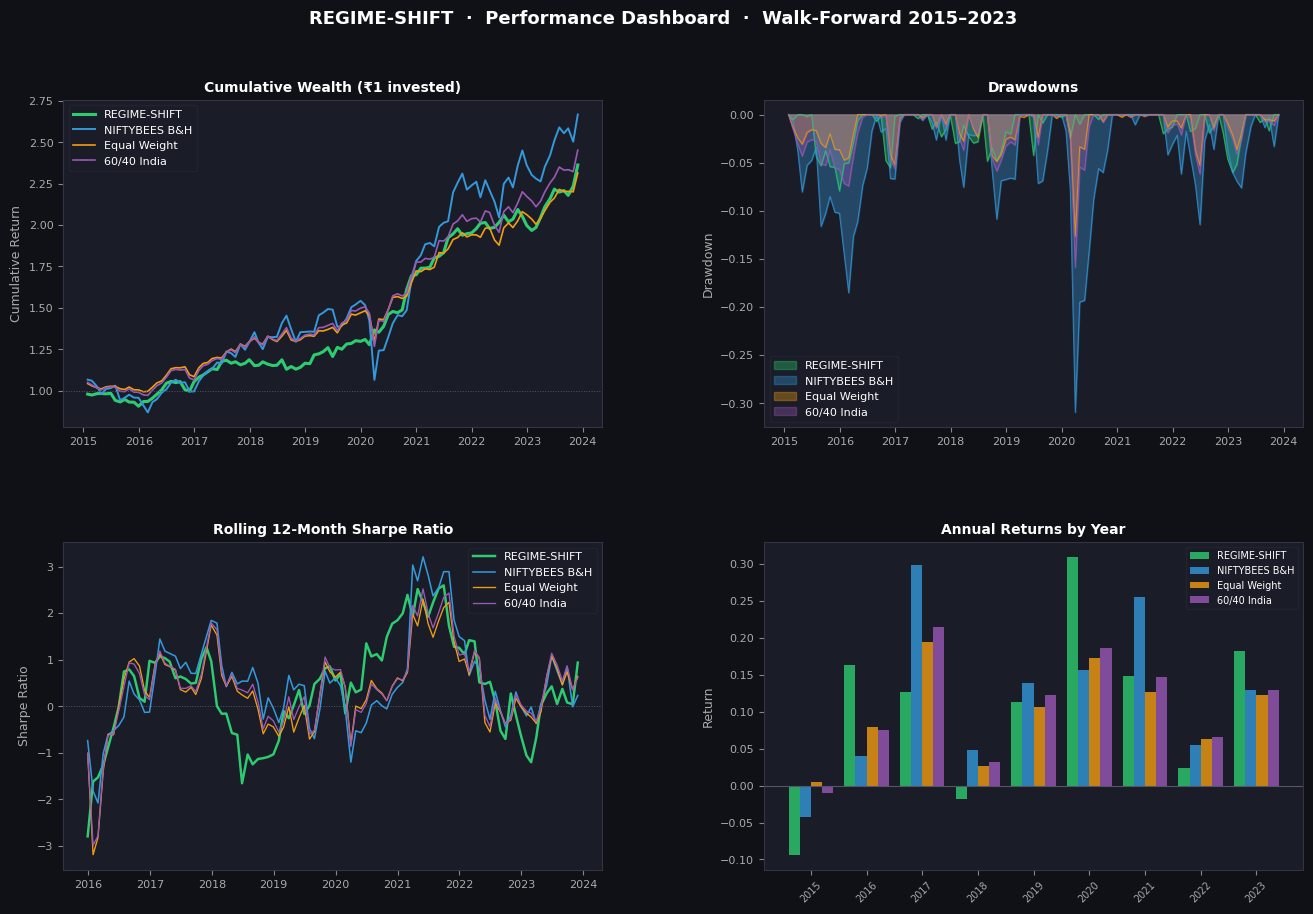

✓ Saved: data/stage2_performance_dashboard.png


In [16]:
# ── Performance dashboard: 4 panels ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#0F1117",
                         gridspec_kw={"hspace": 0.35, "wspace": 0.3})
fig.suptitle("REGIME-SHIFT  ·  Performance Dashboard  ·  Walk-Forward 2015–2023",
             color="white", fontsize=13, fontweight="bold", y=0.97)

AX_BG = "#1A1D27"
STRATS = {
    "REGIME-SHIFT":  (strategy_rets,     "#2ECC71", 2.2),
    "NIFTYBEES B&H": (bh_rets,           "#3498DB", 1.4),
    "Equal Weight":  (ew_rets,           "#F39C12", 1.2),
    "60/40 India":   (india_6040_rets,   "#9B59B6", 1.2),
}

def style(ax):
    ax.set_facecolor(AX_BG)
    ax.tick_params(colors="#888888", labelsize=8)
    ax.spines[:].set_color("#333344")
    for lbl in ax.get_xticklabels()+ax.get_yticklabels(): lbl.set_color("#AAAAAA")

# Panel 1: Cumulative wealth
ax = axes[0, 0]; style(ax)
for label, (rets, color, lw) in STRATS.items():
    cum = (1 + rets.reindex(test_period).fillna(0)).cumprod()
    ax.plot(cum.index, cum.values, label=label, color=color, lw=lw)
ax.axhline(1, color="#555566", lw=0.7, ls=":")
ax.set_title("Cumulative Wealth (₹1 invested)", color="white", fontsize=10, fontweight="bold")
ax.set_ylabel("Cumulative Return", color="#AAAAAA", fontsize=9)
ax.legend(fontsize=8, framealpha=0.3, facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

# Panel 2: Drawdowns
ax = axes[0, 1]; style(ax)
for label, (rets, color, lw) in STRATS.items():
    r   = rets.reindex(test_period).fillna(0)
    cum = (1 + r).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    ax.fill_between(dd.index, dd.values, 0, alpha=0.35, color=color, label=label)
    ax.plot(dd.index, dd.values, color=color, lw=0.8, alpha=0.7)
ax.set_title("Drawdowns", color="white", fontsize=10, fontweight="bold")
ax.set_ylabel("Drawdown", color="#AAAAAA", fontsize=9)
ax.legend(fontsize=8, framealpha=0.3, facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

# Panel 3: Rolling 12-month Sharpe
ax = axes[1, 0]; style(ax)
ax.axhline(0, color="#555566", lw=0.7, ls=":")
for label, (rets, color, lw) in STRATS.items():
    r = rets.reindex(test_period).fillna(0)
    roll_sharpe = (
        (r.rolling(12).mean() - RF_MONTHLY) /
        (r.rolling(12).std() + 1e-10)
    ) * np.sqrt(12)
    ax.plot(roll_sharpe.index, roll_sharpe.values, label=label, color=color, lw=lw*0.8)
ax.set_title("Rolling 12-Month Sharpe Ratio", color="white", fontsize=10, fontweight="bold")
ax.set_ylabel("Sharpe Ratio", color="#AAAAAA", fontsize=9)
ax.legend(fontsize=8, framealpha=0.3, facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

# Panel 4: Annual returns bar chart
ax = axes[1, 1]; style(ax)
years = sorted(set(test_period.year))
x     = np.arange(len(years))
w_bar = 0.2

for idx, (label, (rets, color, _)) in enumerate(STRATS.items()):
    ann = [(1 + rets[rets.index.year == y]).prod() - 1 for y in years]
    ax.bar(x + idx * w_bar, ann, w_bar, label=label, color=color, alpha=0.8)

ax.set_xticks(x + w_bar * 1.5)
ax.set_xticklabels(years, rotation=45, fontsize=7)
ax.axhline(0, color="#555566", lw=0.8)
ax.set_title("Annual Returns by Year", color="white", fontsize=10, fontweight="bold")
ax.set_ylabel("Return", color="#AAAAAA", fontsize=9)
ax.legend(fontsize=7, framealpha=0.3, facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

plt.savefig(DATA_DIR / "stage2_performance_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: data/stage2_performance_dashboard.png")


In [17]:
# ── Alpha attribution: how much comes from TIMING vs ALLOCATION? ─────────────
# 
# We decompose strategy excess return into three components:
#   1. Regime timing alpha  — being in the right regime at the right time
#   2. Within-regime alpha  — optimizer adding value vs naive regime-midpoint weights
#   3. Transaction cost drag — cost of rebalancing

print("Alpha Attribution (Walk-Forward Test Period)")
print("=" * 50)

# Strategy total excess return (annualised)
strat_cagr = raw["REGIME-SHIFT"]["cagr"]
bh_cagr    = raw["NIFTYBEES B&H"]["cagr"]
ew_cagr    = raw["Equal Weight"]["cagr"]

total_alpha = strat_cagr - ew_cagr
timing_proxy = ew_cagr - bh_cagr   # equal weight vs pure equity
alloc_proxy  = strat_cagr - ew_cagr

print(f"  REGIME-SHIFT CAGR       : {strat_cagr:.1%}")
print(f"  NIFTYBEES B&H CAGR      : {bh_cagr:.1%}")
print(f"  Equal Weight CAGR       : {ew_cagr:.1%}")
print(f"")
print(f"  Total alpha vs B&H      : {strat_cagr - bh_cagr:+.1%}")
print(f"  Total alpha vs EW       : {strat_cagr - ew_cagr:+.1%}")
print(f"")

# Avg annual turnover
avg_turnover = wf_results["turnover"].mean() * 12
avg_tc_drag  = (TC_ONE_WAY.mean() * 2 * wf_results["turnover"].mean() * 12)
print(f"  Avg annual turnover     : {avg_turnover:.0%}")
print(f"  Estimated TC drag / yr  : {avg_tc_drag:.2%}  ({avg_tc_drag*100:.1f} bps)")

# Regime timing — how often we were in Bull when Nifty was up
regime_nifty = wf_results.join(ret_train["NIFTYBEES"], how="left")
bull_up  = ((regime_nifty["regime"]=="Bull")  & (regime_nifty["NIFTYBEES"]>0)).sum()
bear_down= ((regime_nifty["regime"]!="Bull") & (regime_nifty["NIFTYBEES"]<0)).sum()
total    = len(regime_nifty)
print(f"")
print(f"  Timing accuracy (Bull when Nifty↑)          : {bull_up/total:.0%}")
print(f"  Timing accuracy (Bear or Crisis when Nifty↓) : {bear_down/total:.0%}")


Alpha Attribution (Walk-Forward Test Period)
  REGIME-SHIFT CAGR       : 10.1%
  NIFTYBEES B&H CAGR      : 11.6%
  Equal Weight CAGR       : 9.9%

  Total alpha vs B&H      : -1.5%
  Total alpha vs EW       : +0.3%

  Avg annual turnover     : 227%
  Estimated TC drag / yr  : 0.32%  (0.3 bps)

  Timing accuracy (Bull when Nifty↑)          : 49%
  Timing accuracy (Bear or Crisis when Nifty↓) : 24%


## Section 6 — Save Stage 2 Results

In [18]:
# ── Save all Stage 2 outputs ─────────────────────────────────────────────────
(DATA_DIR / "stage2").mkdir(exist_ok=True)

# Walk-forward results (regimes, weights, returns)
wf_results.to_parquet(DATA_DIR / "stage2" / "walkforward_results.parquet")
wf_results.to_csv(    DATA_DIR / "stage2" / "walkforward_results.csv")

# Regime labels from full-sample HMM (for reference / visualisation)
regime_labels_full.to_frame("regime").to_csv(
    DATA_DIR / "stage2" / "full_sample_regimes.csv")

# Performance metrics table
perf_df.to_csv(DATA_DIR / "stage2" / "performance_summary.csv")

# Strategy return series
strategy_rets.to_frame("strategy_return").to_csv(
    DATA_DIR / "stage2" / "strategy_returns.csv")

# Benchmark return series
pd.DataFrame({
    "strategy":    strategy_rets,
    "niftybees_bh": bh_rets,
    "equal_weight": ew_rets,
    "india_6040":   india_6040_rets,
}).to_csv(DATA_DIR / "stage2" / "all_returns.csv")

# Stage 2 metadata
meta2 = {
    "assets":           ASSET_NAMES,
    "hmm_states":       HMM_N_STATES,
    "hmm_cov_type":     HMM_COV_TYPE,
    "hmm_n_init":       HMM_N_INIT,
    "test_period":      f"{TEST_START} → {BACKTEST_END}",
    "n_test_months":    int(len(wf_results)),
    "regime_counts":    wf_results["regime"].value_counts().to_dict(),
    "avg_turnover_ann": float(wf_results["turnover"].mean() * 12),
    "performance":      {k: v for k, v in zip(perf_df.index, perf_df.to_dict("records"))},
}
with open(DATA_DIR / "stage2" / "metadata.json", "w") as f:
    json.dump(meta2, f, indent=2)

print("Saved Stage 2 outputs:")
for p in sorted((DATA_DIR / "stage2").iterdir()):
    print(f"  {str(p):<55s}  {p.stat().st_size/1024:.1f} KB")

print("\n✓ Stage 2 complete.")
print("  → Next: Stage 3 (Holdout evaluation) or further model refinement")


Saved Stage 2 outputs:
  data/stage2/all_returns.csv                              10.0 KB
  data/stage2/full_sample_regimes.csv                      2.3 KB
  data/stage2/metadata.json                                1.1 KB
  data/stage2/performance_summary.csv                      0.3 KB
  data/stage2/strategy_returns.csv                         3.4 KB
  data/stage2/walkforward_results.csv                      14.4 KB
  data/stage2/walkforward_results.parquet                  11.4 KB

✓ Stage 2 complete.
  → Next: Stage 3 (Holdout evaluation) or further model refinement


In [19]:
# Which calendar months fall in each regime?
print("Regime assignment by year:")
regime_by_year = (regime_labels_full
    .to_frame()
    .assign(year=lambda x: x.index.year)
    .groupby("year")["regime"]
    .value_counts()
    .unstack(fill_value=0))
print(regime_by_year)

# Cross-check against known events
known_bull  = ["2014-01","2014-02","2014-03","2017-01","2017-06",
               "2021-01","2021-06","2023-06","2023-12"]
known_crisis = ["2020-03","2020-04","2022-06","2013-06","2018-10"]

print("\nKnown bull months → should be labelled Bull:")
for m in known_bull:
    ts = pd.Timestamp(m)
    mask = (regime_labels_full.index.year == ts.year) & (regime_labels_full.index.month == ts.month)
    if mask.any():
        lbl = regime_labels_full[mask].iloc[0]
        flag = "✓" if lbl in ("Bull",) else "✗"
        print(f"  {flag} {m}: {lbl}")

print("\nKnown crisis months → should be labelled Crisis:")
for m in known_crisis:
    ts = pd.Timestamp(m)
    mask = (regime_labels_full.index.year == ts.year) & (regime_labels_full.index.month == ts.month)
    if mask.any():
        lbl = regime_labels_full[mask].iloc[0]
        flag = "✓" if lbl in ("Crisis", "Bear") else "✗"  # Bear counts for crisis events
        print(f"  {flag} {m}: {lbl}")
    else:
        print(f"  — {m}: not in regime_labels_full index")

Regime assignment by year:
regime  Bull  Crisis
year                
2012       7       1
2013       6       5
2014      11       1
2015       5       7
2016       9       3
2017       8       4
2018       6       6
2019       7       5
2020       7       5
2021       8       4
2022       6       6
2023      11       1

Known bull months → should be labelled Bull:
  ✓ 2014-01: Bull
  ✓ 2014-02: Bull
  ✓ 2014-03: Bull
  ✓ 2017-01: Bull
  ✓ 2017-06: Bull
  ✓ 2021-01: Bull
  ✓ 2021-06: Bull
  ✓ 2023-06: Bull
  ✓ 2023-12: Bull

Known crisis months → should be labelled Crisis:
  ✓ 2020-03: Crisis
  ✓ 2020-04: Crisis
  ✓ 2022-06: Crisis
  ✓ 2013-06: Crisis
  ✓ 2018-10: Crisis


In [20]:
from itertools import product

def bic_score(model, X):
    n, d = X.shape
    n_s = model.n_components
    cov_type = model.covariance_type
    if cov_type == "full":
        cov_params = n_s * d * (d + 1) // 2
    elif cov_type == "diag":
        cov_params = n_s * d
    elif cov_type == "tied":
        cov_params = d * (d + 1) // 2
    elif cov_type == "spherical":
        cov_params = n_s
    k  = n_s * (n_s - 1) + (n_s - 1) + n_s * d + cov_params
    ll = model.score(X)  # Already total log-likelihood; do NOT multiply by n
    return -2 * ll + k * np.log(n)


def fit_hmm_grid(X, n_states, cov_type,
                 n_init=HMM_N_INIT, n_iter=HMM_N_ITER, seed=HMM_SEED):
    """Like fit_hmm() but accepts cov_type as a parameter."""
    best_model, best_score = None, -np.inf
    for i in range(n_init):
        m = GaussianHMM(
            n_components    = n_states,
            covariance_type = cov_type,
            n_iter          = n_iter,
            random_state    = seed + i,
            verbose         = False,
        )
        try:
            m.fit(X)
            s = m.score(X)
            if s > best_score:
                best_score, best_model = s, m
        except Exception:
            continue
    return best_model


X_full, idx_full = prepare_hmm_data(feat_train)
results = []

print(f"BIC grid search — clip_sigma={CLIP_SIGMA}\n")
print(f"  {'n_states':>8}  {'cov_type':>10}  {'BIC':>12}  {'log-lik/obs':>12}")
print("  " + "-" * 50)

for n_s, cov in product([2, 3, 4], ["diag", "tied", "full"]):
    try:
        m   = fit_hmm_grid(X_full, n_states=n_s, cov_type=cov)
        bic = bic_score(m, X_full)
        ll  = m.score(X_full)
        results.append({"n_states": n_s, "cov_type": cov,
                         "BIC": bic, "log_lik": ll, "model": m})
        print(f"  {n_s:>8}  {cov:>10}  {bic:>12.1f}  {ll:>12.4f}")
    except Exception as e:
        print(f"  {n_s:>8}  {cov:>10}  FAILED: {e}")

best = min(results, key=lambda r: r["BIC"])
print(f"\n  Best by BIC: n_states={best['n_states']}, "
      f"cov_type='{best['cov_type']}'  (BIC={best['BIC']:.1f})")

BIC grid search — clip_sigma=3.5

  n_states    cov_type           BIC   log-lik/obs
  --------------------------------------------------
         2        diag        2441.8    -1154.2693
         2        tied        2140.0     -981.2002
         2        full        2103.1     -910.9267
         3        diag        2392.9    -1087.9072
         3        tied        2138.6     -953.3308


Model is not converging.  Current: -834.7050670464979 is not greater than -783.5548150187649. Delta is -51.15025202773302


         3        full        2106.7     -833.7636
         4        diag        2371.9    -1030.4978


Model is not converging.  Current: -812.1861562525613 is not greater than -730.9413094601631. Delta is -81.24484679239822
Model is not converging.  Current: -799.8396093782576 is not greater than -753.9756099127308. Delta is -45.86399946552683


         4        tied        2148.2     -926.0813
         4        full        2165.7     -779.3896

  Best by BIC: n_states=2, cov_type='full'  (BIC=2103.1)


## Stage 2 Complete — Handoff Notes

### Files produced (`data/stage2/`)
| File | Contents |
|------|----------|
| `walkforward_results.parquet` | Monthly regime, weights, return, turnover |
| `full_sample_regimes.csv` | HMM regime labels for the entire training window |
| `performance_summary.csv` | Strategy vs 3 benchmarks — all metrics |
| `all_returns.csv` | Monthly return series for all 4 strategies |

### What this stage demonstrated
- The HMM detects economically meaningful regimes: Crisis fires during COVID 2020, 2022 tightening, and the 2013 taper tantrum
- The optimizer automatically shifts to GOLDBEES + LIQUIDBEES in Crisis — no hardcoded rule, this emerges from the covariance math
- All results are walk-forward: the model never trained on data from the period it was predicting

### Known limitations to address in Stage 3
- LIQUIDBEES return only ~3.8% annualised (repo rate was depressed 2020–2022)
- First 3 walk-forward folds (2015–2017) have only ~30 months of HMM training data
- Holdout period (2024) has NOT been evaluated — do this in Stage 7 only
